In [ ]:
# --! include root folder into PYTHONPATH ---------------------------------!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

In [1]:
import torch
import numpy as np
from matplotlib import pyplot as plt

import utils_plot
import kind

# Training our KIND framework on real-world data

### Stationary dataset

The real-world data include a stationary 440 Hz oscillatory signal.


inf >> dataset parameters:

 dataset  batches  timeseries length channels
--------  -------  ----------------- --------
   train     3500                200        1
   valid     1000                200        1
    test      500                200        1



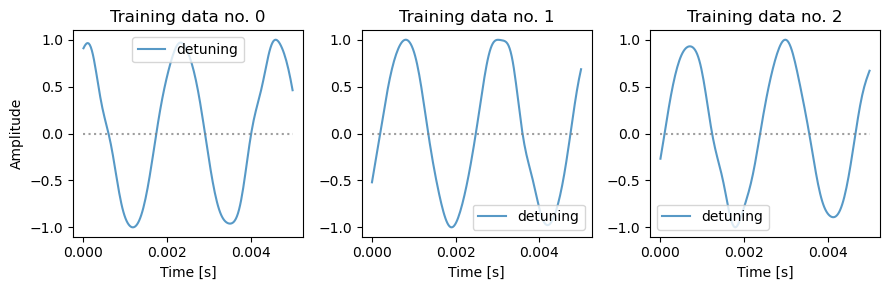

In [2]:
# --!------------------------------------------------------!
# --! display stationary dataset

datadir                = '../../data/care/train_meas_g'
timeseries_ndim        = 1
timeseries_nsample     = 200
timestep               = 2.5e-5

# --! subtimeseries give us additional flexibility by allowing to work with subportions
# --! of original sampled timeseries
subtimeseries_nsample = timeseries_nsample

utils_plot.plot_dataset(datadir, timeseries_nsample, timestep)

### Transient dataset

This dataset features the same 440 Hz oscillatory signal, but additionaly perturbed by a slower oscillation, caused by deliberate mechanical knocks on cavity walls. Therefore, the transient dataset shows time series with rising and falling trends.


inf >> dataset parameters:

 dataset  batches  timeseries length channels
--------  -------  ----------------- --------
   train     3500                200        1
   valid     1000                200        1
    test      500                200        1



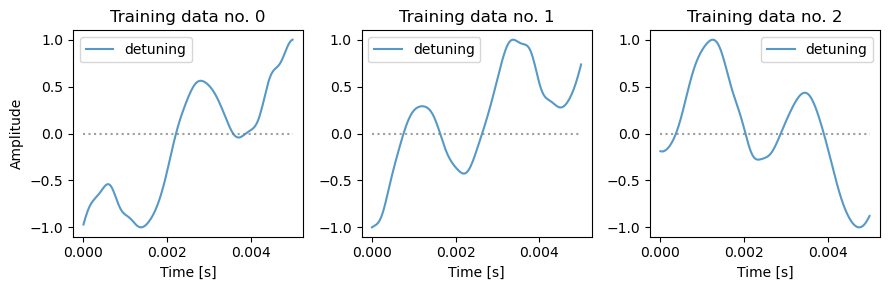

In [3]:
# --!------------------------------------------------------!
# --! display transient dataset

datadir                = '../../data/care/train_meas_l'
timeseries_ndim        = 1
timeseries_nsample     = 200
timestep               = 2.5e-5

# --! subtimeseries give us additional flexibility by allowing to work with subportions
# --! of original sampled timeseries
subtimeseries_nsample = timeseries_nsample

utils_plot.plot_dataset(datadir, timeseries_nsample, timestep)

### Mixed dataset

The mixed dataset contains a mix of stationary and transient time series. We do not show this dataset here explicitly.

### Model instantiation

As in the synthetic case, the model is instantiated with 6 basis functions: a sine and a cosine, as well as 4 polynomials (orders 1 to 4). We also set parameter $\tau=40$ to align with the synthetic example. Of course, as our real-world data feature a single oscillatory mode then the DMD-like stationary operator will identify only one working complex pair of eigenvalues.

In [4]:
# --!--------------------------------------------------------------------------
# --! instantiate a model

# --! ensure reproducible results
#seed = 5
#torch.manual_seed(seed)

model_cfg = kind.model_config(

    timeseries_ndim     = timeseries_ndim,
    timeseries_nsample  = subtimeseries_nsample,
    timestep            = timestep,

    fun = {
        'poly_1' : 1,
        'poly_2' : 1,
        'poly_3' : 1,
        'poly_4' : 1,
        'sin'    : 2,
        'cos'    : 2
    },

    param_kernsize    = 40,
)

model = kind.model(model_cfg)

### Model training

The model is trained in one loop. That is, the mean of the stationary operator is trained first, then its variance, then the mean of the dynamic operator and so on.

In [5]:
# --!--------------------------------------------------------------------------
# --! train all phases in one loop

# --! number of timeseries in one batch
batsize = 128

trainparam = {
    'stadatadir'            : '../../data/care/train_meas_g',
    'transdatadir'          : '../../data/care/train_meas_l',
    'mixdatadir'            : '../../data/care/train_meas_mix',
    'timeseries_nsample'    : timeseries_nsample,
    'subtimeseries_nsample' : subtimeseries_nsample,
    'train_nfile'           : 7,
    'batsize'               : batsize,
    'nepoch'                : 100,
    'isverbose'             : True,
    'learnrate'             : 1e-3,
    'weightdecay'           : 1e-4
}

loss = []

while True:
    loss.append(model.fit(trainparam))
    if not model.fit_next():
        break

inf >> fit: entering stationary mean phase
inf >> number of data files for training is 7
inf >> processing training file number 1
inf >> processing training file number 2
inf >> processing training file number 3
inf >> processing training file number 4
inf >> processing training file number 5
inf >> processing training file number 6
inf >> processing training file number 7
inf >> fit: entering stationary variance phase
inf >> number of data files for training is 7
inf >> processing training file number 1
inf >> processing training file number 2
inf >> processing training file number 3
inf >> processing training file number 4
inf >> processing training file number 5
inf >> processing training file number 6
inf >> processing training file number 7
inf >> fit: entering dynamic mean phase
inf >> number of data files for training is 7
inf >> processing training file number 1
inf >> processing training file number 2
inf >> processing training file number 3
inf >> processing training file num

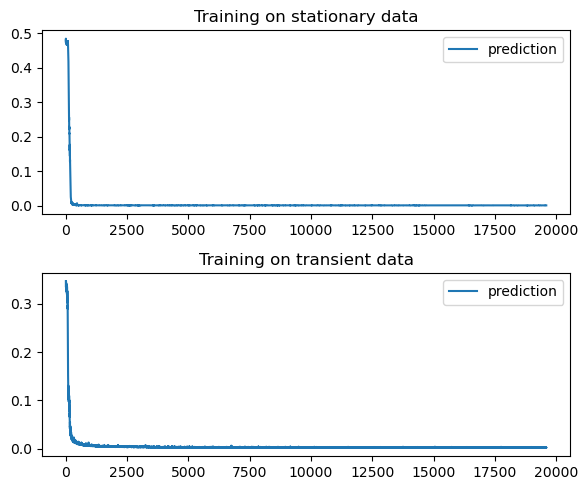

In [6]:
# --!--------------------------------------------------------------------------
# --! plot training statistics

with torch.no_grad():
    sta_stats = loss[0]
    dyn_stats = loss[2]

    plt.figure(figsize=(6, 5))

    plt.subplot(2, 1, 1)
    plt.title('Training on stationary data')
    plt.plot(sta_stats[0], label='prediction')
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.title('Training on transient data')
    plt.plot(dyn_stats[0], label='prediction')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [7]:
# --!--------------------------------------------------------------------------
# --! save a trained global model

savemod_on = True
print(model.operator_sta.model.weight)

if savemod_on:
    torch.save(model, '../../models/care/kind_meas.pt')

Parameter containing:
tensor([[-2.3455e-01, -7.2075e-01,  6.8811e-01,  8.8969e-01, -2.3497e-04,
         -1.4339e-01],
        [-2.7124e-01,  9.5315e-02, -1.9861e-02, -2.9358e-02, -8.9835e-04,
          1.5980e-01],
        [ 2.0822e-01, -1.5036e-01,  1.1923e-01,  1.8666e-01,  1.7648e-03,
         -4.5478e-01],
        [ 3.5067e-01,  4.9415e-02,  2.4475e-02, -6.8264e-02, -1.5376e-04,
         -2.1594e-01],
        [ 4.0918e-05,  3.3850e-05, -3.5579e-05, -4.5161e-05,  1.3334e-04,
         -2.3733e-05],
        [-5.9751e-01,  4.4156e-02, -4.3606e-01,  1.0427e-01,  5.4201e-04,
         -7.1105e-01]])
